<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [11]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [12]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [13]:
## Write your code here
print(f"Dataset Shape: {df.shape}")

print("\n---Summary Informatiom---")
print(df.info())

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (65437, 114)

---Summary Informatiom---
<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
None

Column Names:
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'Too

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [15]:
## Write your code here
print("Missing values per column:")
print(df[['YearsCodePro', 'Employment', 'RemoteWork']].isnull().sum())

# If we don't know their years of experience, we can't correlate it!
df.dropna(subset=['YearsCodePro', 'Employment','JobSat'], inplace=True)

# If they didn't answer RemoteWork, just call it 'Unknown'
df['RemoteWork'] = df['RemoteWork'].fillna('Unknown')

print("\nMissing values after cleaning:")
print(df[['YearsCodePro', 'Employment', 'RemoteWork']].isnull().sum())

Missing values per column:
YearsCodePro    13827
Employment          0
RemoteWork      10631
dtype: int64

Missing values after cleaning:
YearsCodePro    0
Employment      0
RemoteWork      0
dtype: int64


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [16]:
## Write your code here
# 1. Employment Distribution (Who are these people?)
print("--- Employment Type (%) ---")
print(df['Employment'].value_counts(normalize=True).head(5) * 100)

# 2. Job Satisfaction (Are they happy?)
print("\n--- Job Satisfaction Count ---")
print(df['JobSat'].value_counts())

# 3. Professional Experience (Top 5 most common year counts)
print("\n--- Years of Pro Experience (Top 5) ---")
print(df['YearsCodePro'].value_counts().head(5))

--- Employment Type (%) ---
Employment
Employed, full-time                                                         77.242912
Employed, full-time;Independent contractor, freelancer, or self-employed     7.867823
Independent contractor, freelancer, or self-employed                         4.380025
Employed, part-time                                                          1.872620
Employed, full-time;Student, part-time                                       1.720976
Name: proportion, dtype: float64

--- Job Satisfaction Count ---
JobSat
8.0     7325
7.0     6243
6.0     3651
9.0     3557
10.0    2196
5.0     1869
3.0     1141
4.0     1097
2.0      736
0.0      284
1.0      257
Name: count, dtype: int64

--- Years of Pro Experience (Top 5) ---
YearsCodePro
3     2261
2     2153
5     2016
10    1918
4     1866
Name: count, dtype: int64


### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


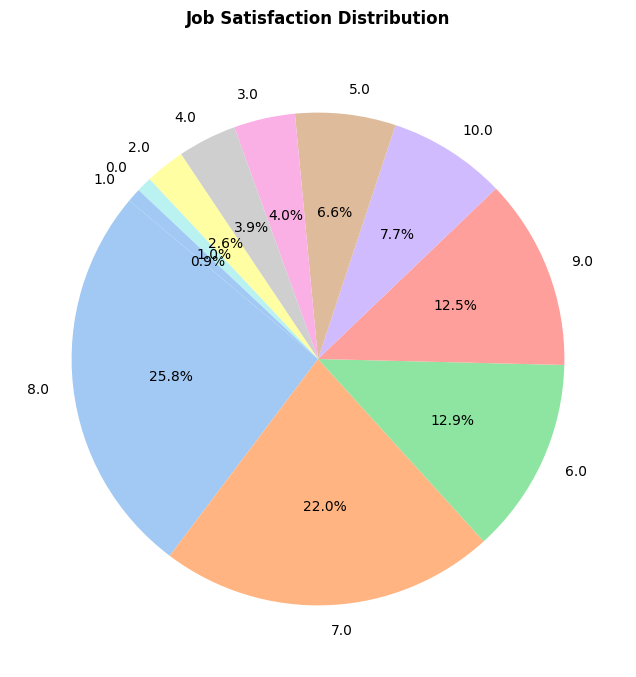

In [25]:
## Write your code here
satisfaction = df['JobSat'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(satisfaction, labels=satisfaction.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'))
                                   
plt.title('Job Satisfaction Distribution', pad=20, fontweight='bold')
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


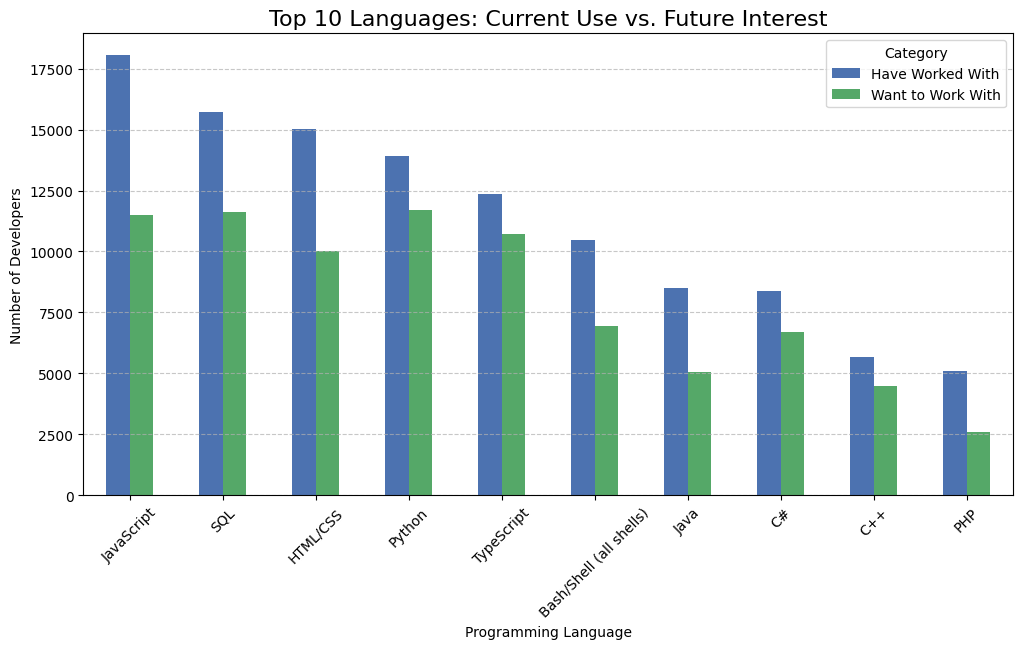

In [26]:
## Write your code here
# 1. SPLIT and EXPLODE (Turns "Python;SQL" into two separate rows)
# We do this for both "Have Worked With" and "Want to Work With"
have_worked = df['LanguageHaveWorkedWith'].str.split(';').explode().value_counts()
want_worked = df['LanguageWantToWorkWith'].str.split(';').explode().value_counts()

# 2. COMBINE into one mini-table
# We only look at the Top 10 most popular "Have" languages to keep it simple
comparison = pd.DataFrame({
    'Have Worked With': have_worked,
    'Want to Work With': want_worked
}).sort_values(by='Have Worked With', ascending=False).head(10)

# 3. PLOT the Grouped Bar Chart
comparison.plot(kind='bar', figsize=(12, 6), color=['#4C72B0', '#55A868'])

# 4. POLISH
plt.title('Top 10 Languages: Current Use vs. Future Interest', fontsize=16)
plt.ylabel('Number of Developers')
plt.xlabel('Programming Language')
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


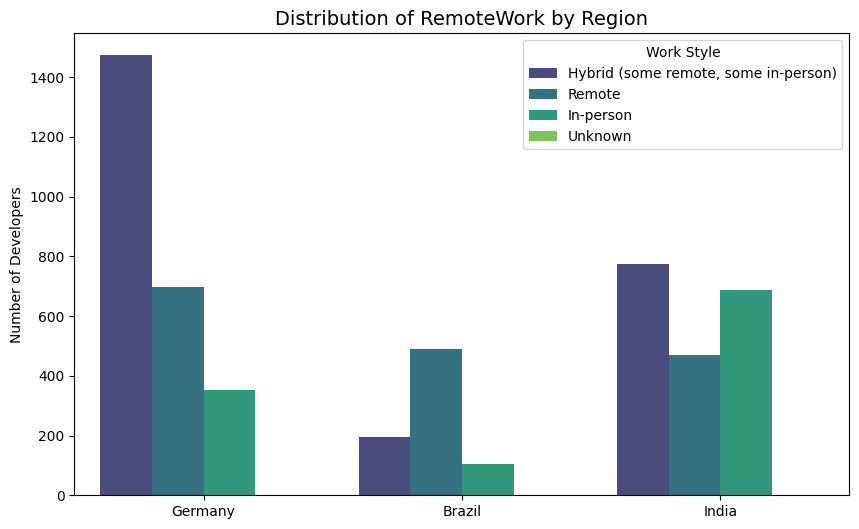

In [28]:
## Write your code here
# 1. Pick 4 big countries to represent "Regions" (keeps it simple!)
countries = ['United States', 'India', 'Germany', 'Brazil']
df_simple = df[df['Country'].isin(countries)].copy()

# 2. Rename the column for the chart (Optional but looks better)
df_simple = df_simple.rename(columns={'Country': 'Region'})

# 3. THE PLOT (One line does all the counting and grouping)
plt.figure(figsize=(10, 6))
sns.countplot(data=df_simple, x='Region', hue='RemoteWork', palette='viridis')

# 4. POLISH
plt.title('Distribution of RemoteWork by Region', fontsize=14)
plt.ylabel('Number of Developers')
plt.xlabel('') # Clean up the bottom axis
plt.legend(title='Work Style')
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [29]:
## Write your code here
# 1. Use the numeric satisfaction column we already established
# If it's still text, we convert it once and move on
df['JobSat_Numeric'] = pd.to_numeric(df['JobSat'], errors='coerce')

# 2. Ensure YearsCodePro is numeric (handling the 'Less than 1' strings)
df['YearsCodePro_Numeric'] = pd.to_numeric(
    df['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 51}), 
    errors='coerce'
)
# 3. Calculate Correlation (Spearman is best for ranked/ordinal data)
correlation = df[['YearsCodePro_Numeric', 'JobSat_Numeric']].corr(method='spearman').iloc[0, 1]

print(f"Spearman Correlation: {correlation:.4f}")

Spearman Correlation: 0.1192


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


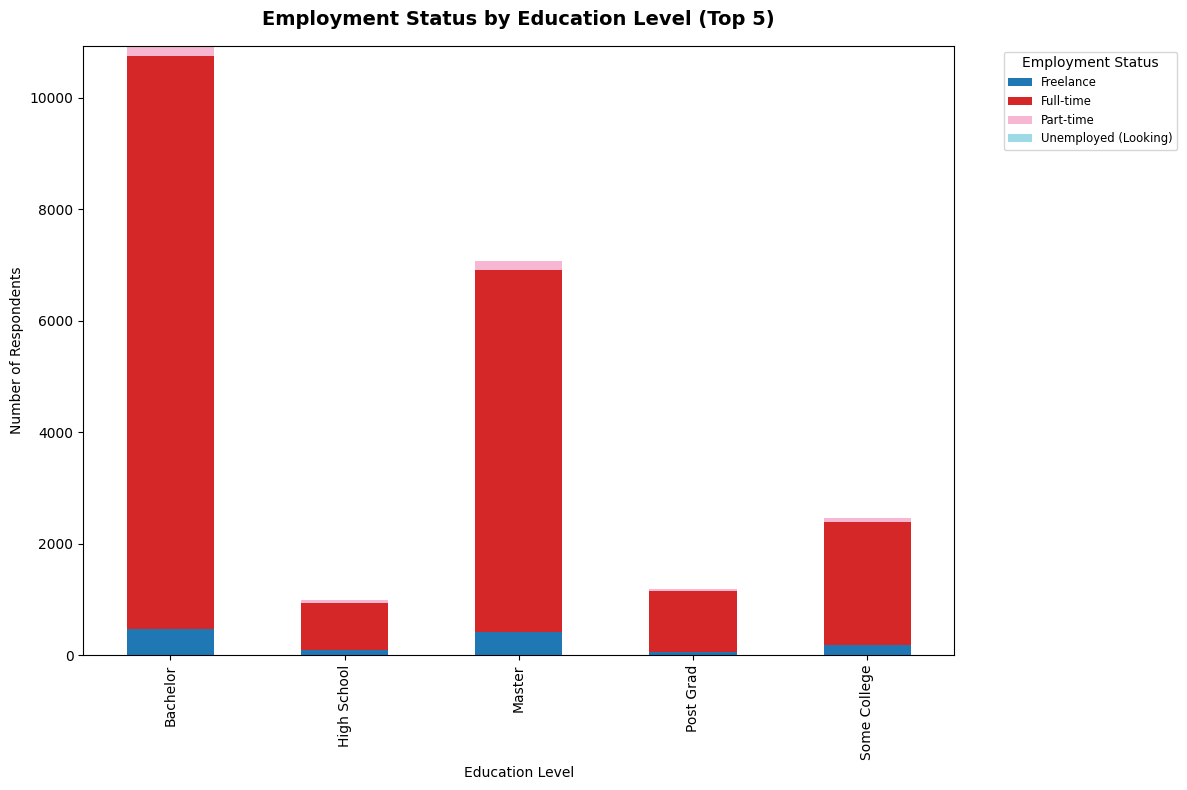

In [47]:
## Write your code here
# 1. CLEANING: Shorten the long Education strings
ed_map = {
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 'Bachelor',
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 'Master',
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 'Post Grad',
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 'High School',
    'Some college/university study without earning a degree': 'Some College'
}
df['Ed_Clean'] = df['EdLevel'].replace(ed_map)

# 2. CLEANING: Shorten Employment and prevent duplicate "Employed" names
emp_map = {
    'Employed, full-time': 'Full-time',
    'Employed, part-time': 'Part-time',
    'Independent contractor, freelancer, or self-employed': 'Freelance',
    'Not employed, but looking for work': 'Unemployed (Looking)',
}
df['Emp_Clean'] = df['Employment'].map(emp_map)

# 3. CROSSTAB: Create the table for Top 5 Education levels
# Filtering first ensures the chart isn't cluttered
top5_ed = df['Ed_Clean'].value_counts().nlargest(5).index
df_filtered = df[df['Ed_Clean'].isin(top5_ed)]

ct = pd.crosstab(df_filtered['Ed_Clean'], df_filtered['Emp_Clean'])

ax = ct.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')

plt.title('Employment Status by Education Level (Top 5)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Education Level')
plt.ylabel('Number of Respondents')
plt.legend(title='Employment Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()

plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [ ]:
## Write your code here


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
